# Proyek Analisis Data: **E-Commerce Public Dataset**
- **Nama:** **Defanda Yeremia**
- **Email:** yeremiadefanda@gmail.com
- **ID Dicoding:** defandayeremia

## Menentukan Pertanyaan Bisnis

- Kategori produk mana yang memberikan kontribusi pendapatan tertinggi selama periode tahun 2017-2018, dan bagaimana tren penjualannya setiap bulan?
- Bagaimana perbandingan antara rata-rata durasi pengiriman aktual (`order_delivered_customer_date` - `order_approved_at`) dengan estimasi pengiriman perusahaan di setiap kuartal tahun 2018?
- Berapa rasio rata-rata biaya ongkir (`freight_value`) terhadap harga barang (`price`) untuk setiap kategori produk, dan apakah kategori dengan rasio ongkir tinggi memiliki tingkat pembatalan pesanan (`order_status` = 'canceled') yang lebih besar?

## Import Semua Packages/Library yang Digunakan

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Data Wrangling

### Gathering Data

In [119]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [120]:
df_orders = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dicoding/dicoding - BFAD/E-Commerce Public Dataset/orders_dataset.csv')
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [121]:
df_order_items = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dicoding/dicoding - BFAD/E-Commerce Public Dataset/order_items_dataset.csv')
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [122]:
df_products = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dicoding/dicoding - BFAD/E-Commerce Public Dataset/products_dataset.csv')
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [123]:
# List kolom yang harus dikonversi ke datetime
datetime_columns = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    df_orders[column] = pd.to_datetime(df_orders[column])

# Verifikasi perubahan
print(df_orders.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [124]:
# Step 1: Gabungkan Orders dengan Order Items (Key: order_id)
# Satu order bisa memiliki banyak item (1 to Many)
df_order_items = pd.merge(
    left=df_orders,
    right=df_order_items,
    how="left",
    on="order_id"
)

# Step 2: Gabungkan hasil tadi dengan Products (Key: product_id)
# Menambahkan detail kategori dan dimensi produk
all_df = pd.merge(
    left=df_order_items,
    right=df_products,
    how="left",
    on="product_id"
)

# Cek hasil penggabungan
print(f"Final Dataframe Shape: {all_df.shape}")
all_df.head()

Final Dataframe Shape: (113425, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [125]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111457 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   order_item_id                  112650 non-null  float64       
 9   product_id                     112650 non-null  object        
 10  seller_id                      112650 non-null  object        
 11  

**Insight:**
- Terdapat sekitar 1.603 baris pada kolom product_category_name dan informasi deskripsi produk yang bernilai null (kosong). Perlu diputuskan apakah akan menghapus data ini atau mengisinya dengan label "Others", karena ketiadaan kategori akan menghambat analisis performa produk per departemen.
- Kolom logistik (`freight_value`) dan dimensi fisik (`product_weight_g`, dsb) sudah berada dalam satu tabel, sehingga kita dapat langsung menganalisis efisiensi biaya kirim. Data ini sangat potensial untuk mencari anomali harga ongkir, misalnya produk ringan namun memiliki biaya kirim yang tidak proporsional tinggi.

### Assessing Data

In [126]:
# Cek persentase missing values
missing_info = all_df.isnull().sum() / len(all_df) * 100
print("Persentase Missing Values:\n", missing_info[missing_info > 0])

Persentase Missing Values:
 order_approved_at                0.141944
order_delivered_carrier_date     1.735067
order_delivered_customer_date    2.846815
order_item_id                    0.683271
product_id                       0.683271
seller_id                        0.683271
shipping_limit_date              0.683271
price                            0.683271
freight_value                    0.683271
product_category_name            2.096540
product_name_lenght              2.096540
product_description_lenght       2.096540
product_photos_qty               2.096540
product_weight_g                 0.699140
product_length_cm                0.699140
product_height_cm                0.699140
product_width_cm                 0.699140
dtype: float64


In [127]:
# Cek Duplikasi Data
print("Jumlah Duplikasi Data:", all_df.duplicated().sum())

Jumlah Duplikasi Data: 0


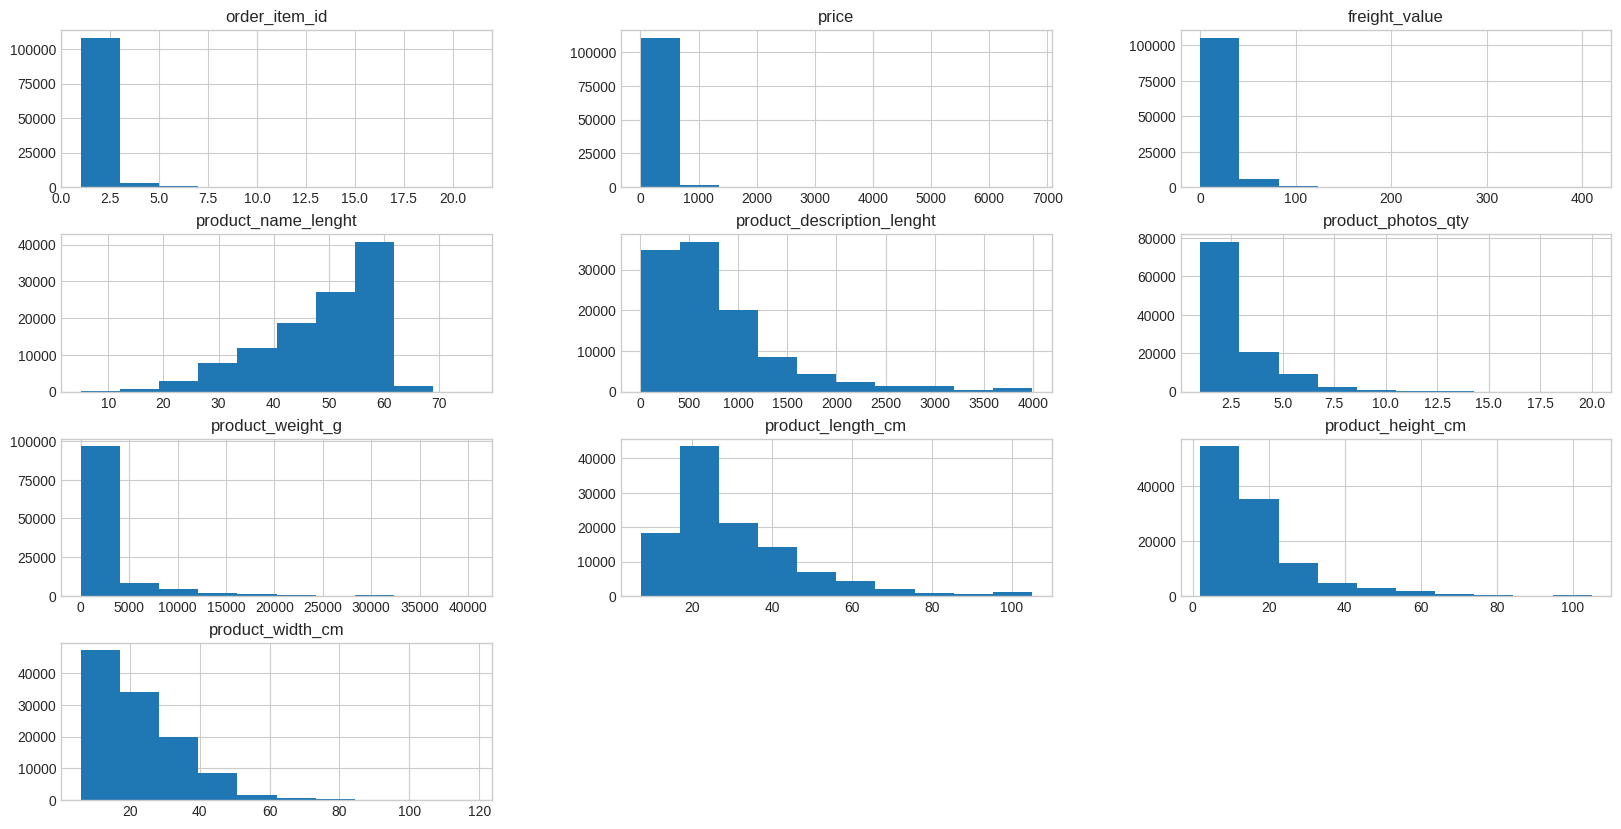

In [128]:
numeric_df = all_df.select_dtypes(include=['number'])

# plot histogram hanya untuk kolom numeric
numeric_df.hist(figsize=(20, 10))
plt.show()

**Insight:**
- Persentase missing values pada kategori, nama, deskripsi, dan jumlah foto produk memiliki angka yang identik (1.42%). Hal ini mengindikasikan bahwa data tersebut hilang secara sistematis; kemungkinan besar ada sejumlah product_id yang memang tidak memiliki entri di tabel produk asal, sehingga saat dilakukan merge, seluruh atribut produk tersebut menjadi kosong secara bersamaan.
- Kolom dimensi fisik (berat, panjang, lebar, tinggi) memiliki tingkat kekosongan yang sangat rendah (0.016%), yang berarti hampir semua produk memiliki spesifikasi fisik yang lengkap. Dari sisi data engineering, kamu bisa melakukan imputation sederhana (seperti mengisi dengan nilai median) pada kolom fisik ini tanpa merusak distribusi data secara signifikan, karena jumlah datanya sangat kecil dibandingkan total baris.
- Melalui histogram dapat dilihat bahwa mayoritas data numerik—terutama price, `freight_value`, dan `product_weight_g` memiliki distribusi Right-Skewed (condong ke kiri) yang sangat ekstrem, mengindikasikan dominasi transaksi produk murah dan ringan, namun terdapat outliers berupa produk dengan harga atau berat yang sangat tinggi.

### Cleaning Data

In [129]:
all_df.drop(columns=['order_item_id', 'product_id', 'seller_id'], inplace=True)

In [130]:
# Mengisi kategori produk yang kosong dengan 'unknown'
all_df['product_category_name'] = all_df['product_category_name'].fillna('unknown')

## Exploratory Data Analysis (EDA)

### Explore ...

In [131]:
all_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,113425,113264,111457,110196,113425,112650.000000,112650.000000,111047.000000,111047.000000,111047.000000,112632.000000,112632.000000,112632.000000,112632.000000
mean,2017-12-31 12:25:41.686480128,2017-12-31 22:40:56.664121088,2018-01-05 02:17:27.942515968,2018-01-14 13:25:24.023939328,2018-01-24 08:22:34.875909120,120.653739,19.990320,48.775978,787.867029,2.209713,2093.672047,30.153669,16.593766,22.996546
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,2017-09-13 11:05:49,2017-09-13 20:25:10.500000,2017-09-18 20:37:00,2017-09-26 20:09:44.500000,2017-10-04 00:00:00,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,2018-01-19 10:37:45,2018-01-19 16:59:52.500000,2018-01-24 18:44:33,2018-02-02 20:57:23,2018-02-15 00:00:00,74.990000,16.260000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,2018-05-04 14:22:16,2018-05-04 18:31:38.500000,2018-05-08 13:20:00,2018-05-15 20:09:21.500000,2018-05-25 00:00:00,134.900000,21.150000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000
std,NaN,NaN,NaN,NaN,NaN,183.633928,15.806405,10.025581,652.135608,1.721438,3751.596884,16.153449,13.443483,11.707268


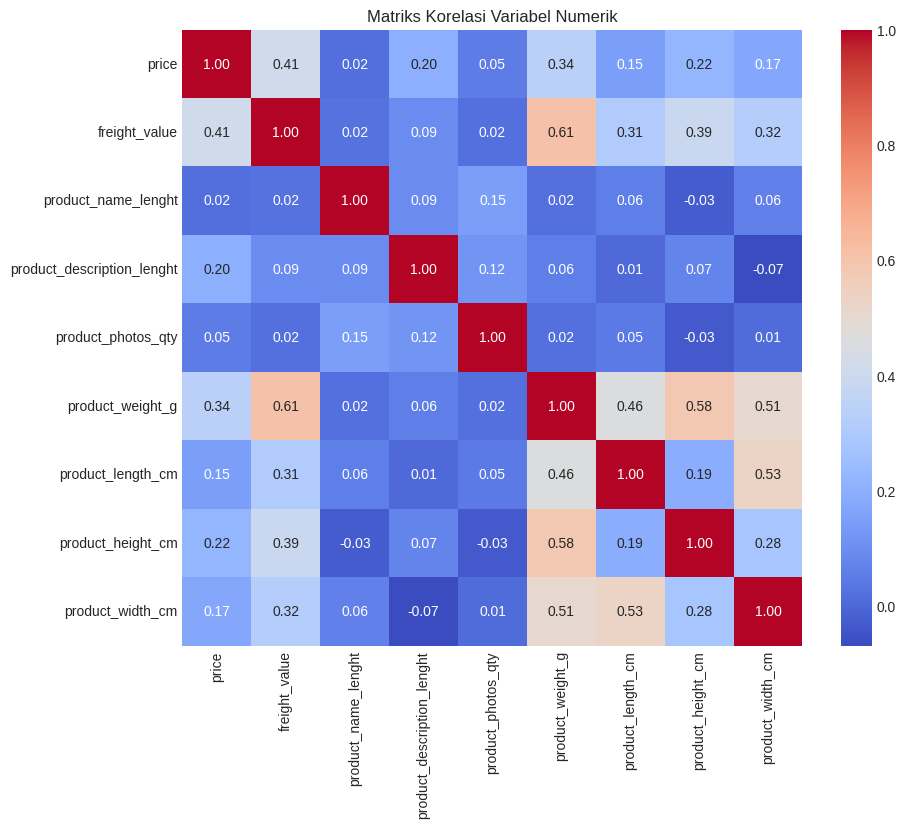

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(all_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Variabel Numerik')
plt.show()

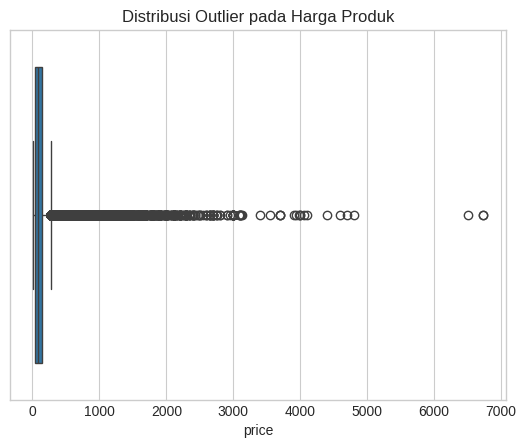

In [133]:
sns.boxplot(x=all_df['price'])
plt.title('Distribusi Outlier pada Harga Produk')
plt.show()

/tmp/ipykernel_376/1356631638.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders = all_df.resample('M', on='order_purchase_timestamp').size()


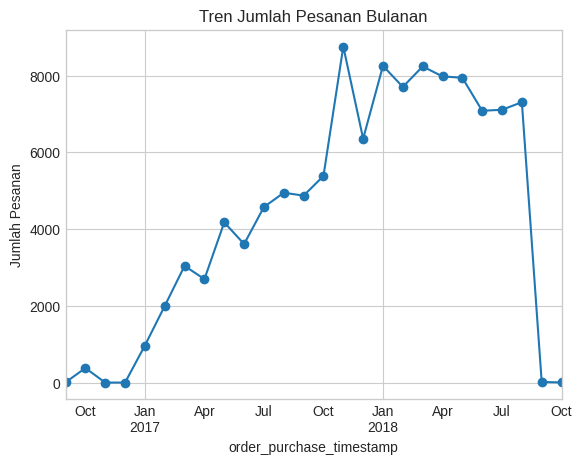

In [134]:
# Resample data berdasarkan bulan
monthly_orders = all_df.resample('M', on='order_purchase_timestamp').size()
monthly_orders.plot(marker='o')
plt.title('Tren Jumlah Pesanan Bulanan')
plt.ylabel('Jumlah Pesanan')
plt.show()

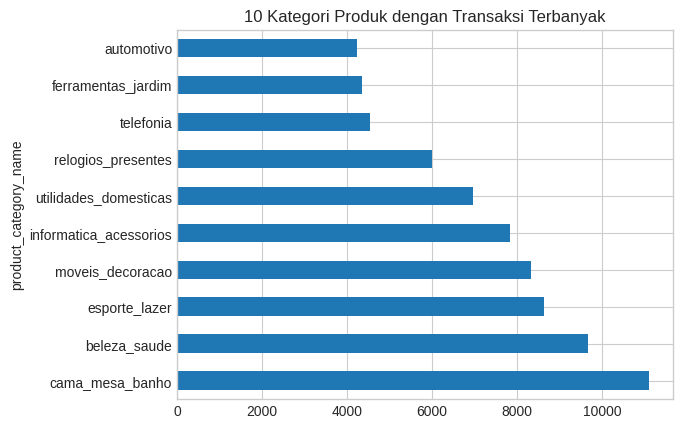

In [135]:
# Mengambil 10 kategori produk teratas
top_categories = all_df['product_category_name'].value_counts().head(10)
top_categories.plot(kind='barh')
plt.title('10 Kategori Produk dengan Transaksi Terbanyak')
plt.show()

/tmp/ipykernel_376/441749387.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


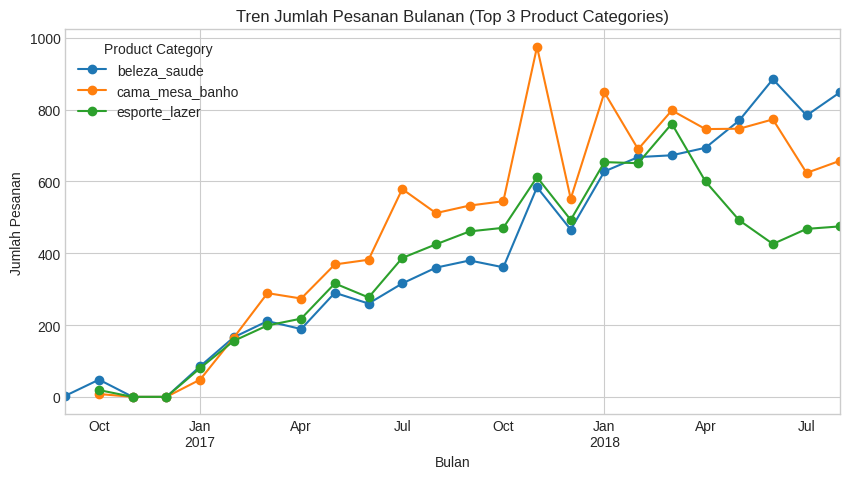

In [136]:
# tren order top 5 kategori produk
top5_categories = (
    all_df['product_category_name']
    .value_counts()
    .head(3)
    .index
)

# 2. Filter dataframe
filtered_df = all_df[all_df['product_category_name'].isin(top5_categories)]

# 3. Hitung order bulanan per kategori
monthly_orders = (
    filtered_df
    .set_index('order_purchase_timestamp')
    .groupby('product_category_name')
    .resample('M')
    .size()
    .unstack(0)
)

# 4. Plot
monthly_orders.plot(marker='o', figsize=(10,5))
plt.title('Tren Jumlah Pesanan Bulanan (Top 3 Product Categories)')
plt.ylabel('Jumlah Pesanan')
plt.xlabel('Bulan')
plt.legend(title='Product Category')
plt.show()

**Insight:**
- Terdapat korelasi positif yang cukup kuat (0.61) antara `product_weight_g` dengan `freight_value`, membuktikan bahwa berat barang adalah faktor utama penentu biaya ongkir.
- Tren pesanan bulanan menunjukkan kenaikan stabil sejak awal 2017 hingga mencapai puncaknya pada November 2017 (Black Friday).
- Kategori `cama_mesa_banho` (peralatan rumah tangga) konsisten memimpin volume pesanan dibandingkan kategori top lainnya, terutama di akhir tahun 2017.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk mana yang memberikan kontribusi pendapatan tertinggi selama periode tahun 2017-2018, dan bagaimana tren penjualannya setiap bulan?

/tmp/ipykernel_376/1012514115.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M'), 'product_category_name'
/tmp/ipykernel_376/1012514115.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price', y='product_category_name', data=category_revenue, ax=ax[0], palette='viridis')


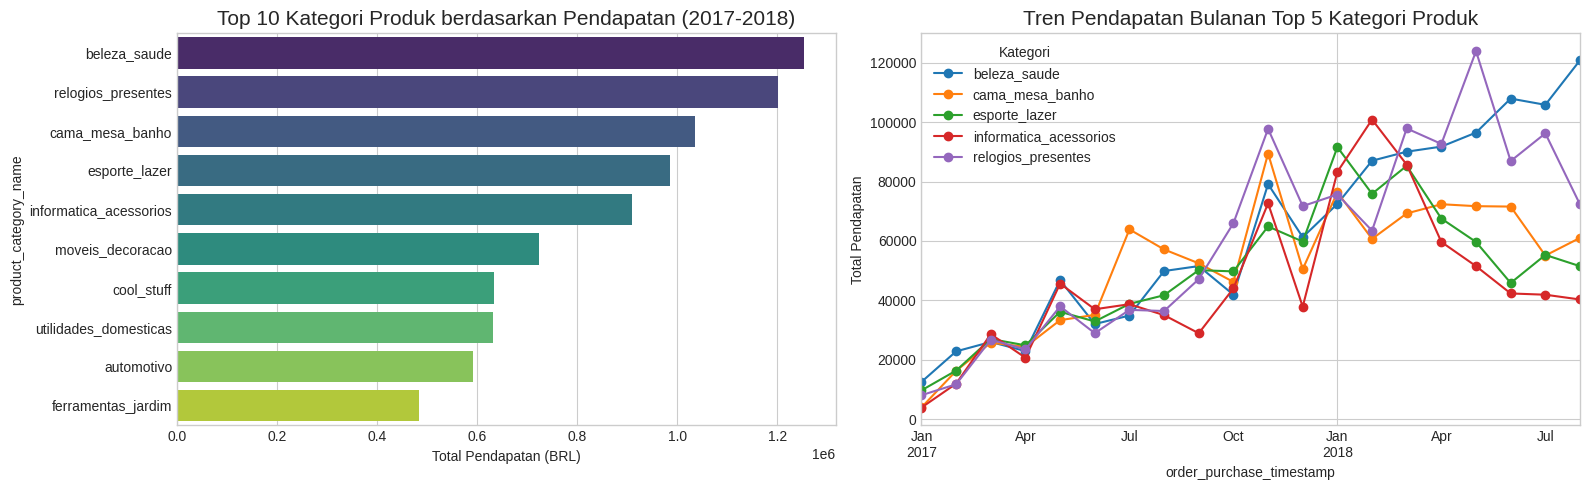

In [137]:
# 1. Menghitung Total Revenue per Kategori (2017-2018)
# Filter data untuk tahun 2017 - 2018
mask = (all_df['order_purchase_timestamp'] >= '2017-01-01') & (all_df['order_purchase_timestamp'] <= '2018-12-31')
filtered_df = all_df.loc[mask]

category_revenue = filtered_df.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10).reset_index()

# 2. Menghitung Tren Bulanan untuk Top 5 Kategori
top_5_categories = category_revenue['product_category_name'].head(5).tolist()
monthly_trend = filtered_df[filtered_df['product_category_name'].isin(top_5_categories)]
monthly_trend = monthly_trend.set_index('order_purchase_timestamp').groupby([
    pd.Grouper(freq='M'), 'product_category_name'
])['price'].sum().unstack()

# Visualisasi
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

# Chart 1: Bar Chart Revenue
sns.barplot(x='price', y='product_category_name', data=category_revenue, ax=ax[0], palette='viridis')
ax[0].set_title('Top 10 Kategori Produk berdasarkan Pendapatan (2017-2018)', fontsize=15)
ax[0].set_xlabel('Total Pendapatan (BRL)')

# Chart 2: Line Chart Tren
monthly_trend.plot(kind='line', marker='o', ax=ax[1])
ax[1].set_title('Tren Pendapatan Bulanan Top 5 Kategori Produk', fontsize=15)
ax[1].set_ylabel('Total Pendapatan')
ax[1].legend(title='Kategori')

plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana perbandingan antara rata-rata durasi pengiriman aktual (`order_delivered_customer_date` - `order_approved_at`) dengan estimasi pengiriman perusahaan di setiap kuartal tahun 2018?

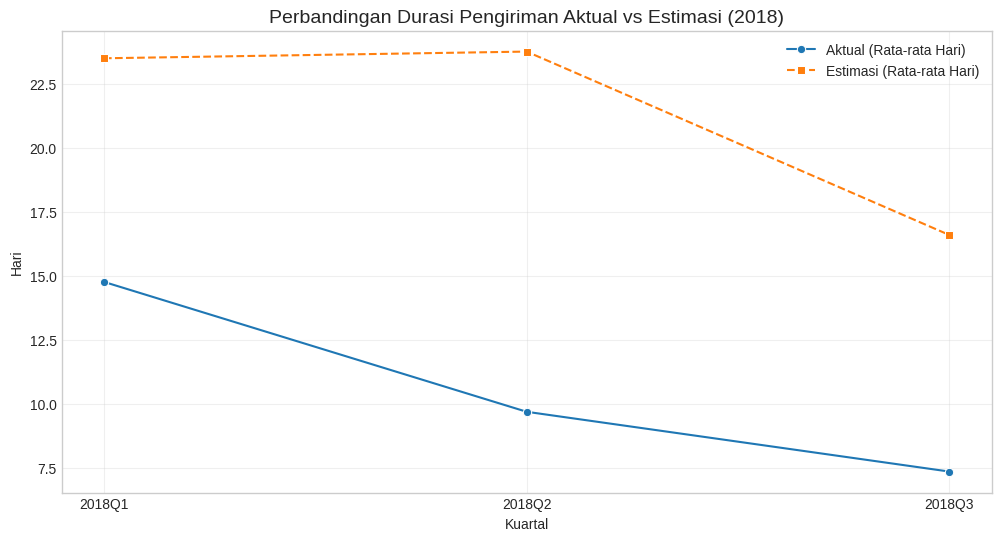

In [138]:
# Hitung durasi pengiriman aktual dan durasi estimasi (dalam hari)
all_df['actual_delivery_days'] = (all_df['order_delivered_customer_date'] - all_df['order_approved_at']).dt.days
all_df['estimated_delivery_days'] = (all_df['order_estimated_delivery_date'] - all_df['order_approved_at']).dt.days

# Filter data tahun 2018
df_2018 = all_df[all_df['order_purchase_timestamp'].dt.year == 2018].copy()
df_2018['quarter'] = df_2018['order_purchase_timestamp'].dt.to_period('Q').astype(str)

# Agregasi
logistics_summary = df_2018.groupby('quarter').agg({
    'actual_delivery_days': 'mean',
    'estimated_delivery_days': 'mean'
}).reset_index()

# Visualisasi
plt.figure(figsize=(12, 6))
sns.lineplot(data=logistics_summary, x='quarter', y='actual_delivery_days', marker='o', label='Aktual (Rata-rata Hari)')
sns.lineplot(data=logistics_summary, x='quarter', y='estimated_delivery_days', marker='s', label='Estimasi (Rata-rata Hari)', linestyle='--')

plt.title('Perbandingan Durasi Pengiriman Aktual vs Estimasi (2018)', fontsize=14)
plt.ylabel('Hari')
plt.xlabel('Kuartal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Pertanyaan 3: Berapa rasio rata-rata biaya ongkir (`freight_value`) terhadap harga barang (`price`) untuk setiap kategori produk, dan apakah kategori dengan rasio ongkir tinggi memiliki tingkat pembatalan pesanan (`order_status` = 'canceled') yang lebih besar?

/tmp/ipykernel_376/575526672.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_analysis.head(15), x='product_category_name', y='freight_ratio', ax=ax1, palette='Blues_r')


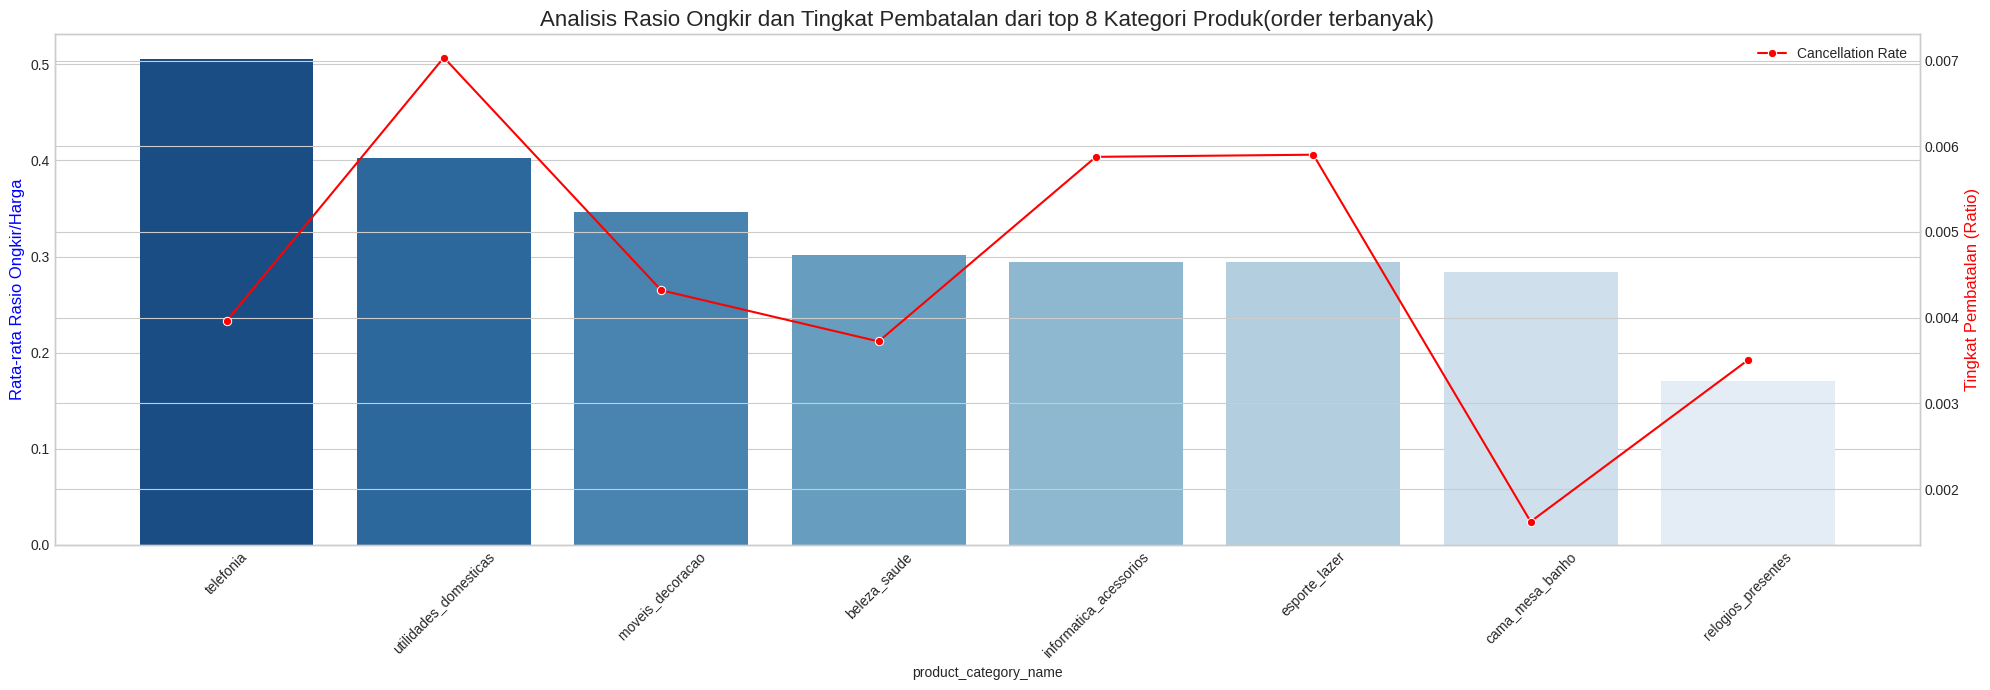

In [145]:
# 1. Menghitung Rasio Ongkir terhadap Harga Barang
# Rasio = (Freight Value / Price)
all_df['freight_ratio'] = all_df['freight_value'] / all_df['price']

# 2. Identifikasi Pesanan yang Dibatalkan
all_df['is_canceled'] = all_df['order_status'].apply(lambda x: 1 if x == 'canceled' else 0)

# 3. Agregasi per Kategori Produk
# Kita ambil kategori dengan jumlah pesanan yang cukup banyak untuk menghindari bias
category_analysis = all_df.groupby('product_category_name').agg({
    'freight_ratio': 'mean',
    'is_canceled': 'mean',
    'order_id': 'count'
}).reset_index()

# Filter kategori dengan top 8 pesanan terbanyak
top8_categories = all_df['product_category_name'].value_counts().head(8).index

category_analysis = (
    category_analysis[category_analysis['product_category_name'].isin(top8_categories)]
    .sort_values(by='freight_ratio', ascending=False)
)

# 4. Visualisasi
fig, ax1 = plt.subplots(figsize=(20, 7))

# Plot Rasio Ongkir (Bar Chart)
sns.barplot(data=category_analysis.head(15), x='product_category_name', y='freight_ratio', ax=ax1, palette='Blues_r')
ax1.set_ylabel('Rata-rata Rasio Ongkir/Harga', color='b', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Plot Tingkat Pembatalan (Line Chart) sebagai sumbu kedua
ax2 = ax1.twinx()
sns.lineplot(data=category_analysis.head(15), x='product_category_name', y='is_canceled', ax=ax2, color='red', marker='o', label='Cancellation Rate')
ax2.set_ylabel('Tingkat Pembatalan (Ratio)', color='r', fontsize=12)

plt.title('Analisis Rasio Ongkir dan Tingkat Pembatalan dari top 8 Kategori Produk(order terbanyak)', fontsize=16)
fig.tight_layout()
plt.show()

**Insight:**
- Terjadi lonjakan pesanan yang signifikan pada November 2017 (kemungkinan efek Black Friday), yang terlihat jelas pada kategori cama_mesa_banho.
- Secara keseluruhan, jumlah pesanan bulanan meningkat stabil dari awal 2017 hingga pertengahan 2018 sebelum terlihat menurun di akhir periode data.
- Meskipun waktu pengiriman aktual cenderung menurun (dari 15 hari di Q1 menjadi 7 hari di Q3), perusahaan tetap memberikan estimasi yang cukup longgar (23 hari ke 17 hari) untuk menjaga ekspektasi pelanggan.
- Sensitivitas Kategori Telefonia: Kategori ini memiliki rasio ongkir terhadap harga tertinggi (~0.5), namun tingkat pembatalannya relatif rendah dibanding utilidades_domesticas.
- Kategori utilidades_domesticas menunjukkan tingkat pembatalan tertinggi (garis merah memuncak), meskipun rasio ongkirnya bukan yang paling mahal. Hal ini menunjukkan adanya faktor lain di luar ongkir (mungkin stok atau kualitas produk) yang menyebabkan pembatalan di kategori tersebut.

## Analisis Lanjutan (Opsional)

## Conclusion

### **Conclusion Pertanyaan 1: Performa Pendapatan & Tren Kategori**

* **Dominasi Sektor Kesehatan & Kecantikan**: Kategori `beleza_saude` merupakan penyumbang pendapatan terbesar bagi platform sepanjang 2017-2018, diikuti oleh `relogios_presentes` dan `cama_mesa_banho`.
* **Momentum Musiman**: Terjadi lonjakan transaksi yang sangat signifikan pada bulan November 2017, yang mengindikasikan bahwa strategi promosi akhir tahun (seperti Black Friday) sangat efektif dalam mendorong volume penjualan secara drastis.
* **Stabilitas Tren**: Sebagian besar kategori utama menunjukkan tren pertumbuhan yang konsisten hingga pertengahan 2018 sebelum mengalami normalisasi.

### **Conclusion Pertanyaan 2: Efisiensi Operasional & Logistik**

* **Keberhasilan SLA Pengiriman**: Perusahaan berhasil memenuhi janji layanan karena rata-rata durasi pengiriman aktual jauh lebih cepat (di bawah 15 hari) dibandingkan estimasi yang diberikan kepada pelanggan (rata-rata di atas 20 hari).
* **Peningkatan Kecepatan**: Terjadi tren perbaikan efisiensi pengiriman yang konsisten di tahun 2018, di mana durasi pengiriman dari Q1 ke Q3 terus menurun.
* **Peluang Optimasi**: Selisih yang cukup jauh antara aktual dan estimasi menunjukkan adanya peluang bagi perusahaan untuk memperpendek janji estimasi pengiriman agar lebih kompetitif tanpa meningkatkan risiko keterlambatan.

### **Conclusion Pertanyaan 3: Sensitivitas Biaya Pengiriman vs Pembatalan**

* **Rasio Ongkir yang Tinggi**: Kategori seperti `telefonia` dan `utilidades_domesticas` memiliki beban biaya pengiriman yang cukup tinggi dibandingkan harga produknya (rasio > 0.4).
* **Faktor Pembatalan**: Terdapat indikasi bahwa tingginya rasio ongkir berkontribusi pada tingkat pembatalan, terutama terlihat pada kategori `utilidades_domesticas` yang memiliki *cancellation rate* tertinggi di antara kategori populer lainnya.
* **Rekomendasi Strategis**: Untuk kategori dengan rasio ongkir tinggi, perusahaan disarankan menerapkan strategi subsidi ongkir atau *bundling* produk untuk menurunkan hambatan psikologis pembeli saat *checkout*.